# Quick Start Guide: PR Assisted RAC Strategy Search Framework


This quick-start notebook demonstrates the search for an optimal strategy for a PR-Assisted RAC. 

## TOC

- [PR Assisted RAC](#sec-pr-assisted-rac)
- [SSF: Strategy Search Framework](#sec-ssf)
- [Geometry](#sec-this-qsg)
- [Overall optimal strategy as a function of p_rule](#sec-overall)
- [Overall optimal strategy with B-side effective box-limit](#sec-b-side-limit)
- [Overall optimal strategy with A-side protocol box-limit](#sec-a-side-limit)
- [Reference](#sec-reference)

<a id="sec-pr-assisted-rac"></a>
## PR Assisted RAC
* In an RAC game player A receives a string of random bit bits, length $n2$. Player B receives an index and has as task to guessthe value of the bit in A's string at the given index. Player A can communicated one bit to player B.

* Player should not learn which index is given to player B, and player B should only learn the bit corresponding to his index with a probability $p$

* As a variation on purely classical RAC's (where A's bits as well as the communication bit are classical) we can evaluate Entanglement Assisted Random Access Code(EA-RAC) as a code
in which the communicated bit is classical, however
the parties are additionally allowed to use shared entangled states during their coding/decoding procedures. 

* As a further variant we can evaluate PR-Assisted RAC's, where parties can use of Popescu-Rohrlich boxes to assist parties in coding and decoding. The correlation strength of these boxes is denoted by $p_{\text{rule}}$. The number of these boxes used by the parties is labelled as $k$.

* A PR-Assisted RAC is characterized by ($n2$,$m$,$k$,$p_{\text{rule}}$) leading to an optimal win rate, i.e., the rate at which player B is able to succesfully guess the correct value. In this notebook we limit ourselves to $n2=4, m=1$ and exploit the impact of $k$ for 0,1,2 and 3 and a range for $p_{\text{rule}}$ between 0.5 and 1.0

References
1. A Grudka, M Horodecki, R Horodecki, A Wójcik, “Nonsignaling quantum random access code boxes, Phys. Rev. A 92, 052312 (2015) https://doi.org/10.48550/arXiv.1403.1295

2. M. Pawlowski and M. Zukowski, “Entanglement Assisted Random Access Codes,” Phys. Rev. A 81, 042326 (2010). https://doi.org/10.48550/arXiv.0906.0524

<a id="sec-ssf"></a>
## SSF: Strategy Search Framework
The SSF package is develop to find the optimal win-rate for a given PR-Assisted RAC geometry. For the relatively small search space defined by $n2=4$ and $k<= 0$ we can perform an exhaustive search. We score every A-side strategy candidate with the performance from the optimal B-side decoding repsonse. 

The A-side search space is the Hybrid family. 

This notebook calls the CLI API (`run_exhaustive_strategy_optimizer.py`) 

It sweeps `p_rule` from `0.50` to `1.00` (inclusive), writes results to JSON, parses the JSON output, and plots the best success per `p_rule`.

Note on runtime cost: `dense_exhaustive` can be expensive. For larger `n2`/`k_box`, switch mode to `analytical`, `dense_mc`, or `procedural_mc`, or reduce `families` / `top_k`.

<a id="sec-this-qsg"></a>
## Geometry
This notebook uses the geometry $n2=4, m=1$ and explores the impact of $k$ for 0,1,2 and 3. We derive the optimal win-rate for $p_{\text{rule}}$ between 0.5 and 1.0

Sections:
1. Optimize the win-rate for the given geometry without restriction on PR-Box utilization
2. Exploit the full search space for A-side strategies, but limit the effective box utilization at B-side.
3. Limit A-side strategies in terms of box utilization, while leaving the B-side optimization unrestricted.


In [1]:
import json
import subprocess
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Path resolution requested in the QSG requirements
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
script_path = project_root / "scripts" / "optimize" /"run_exhaustive_strategy_optimizer.py"
output_path = project_root / "work" / "qsg" / "p_rule_curve_exhaustive.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

# Keep notebook robust with current repository script layout
if not script_path.exists():
    fallback_script = project_root / "scripts" / "optimize" / "run_exhaustive_strategy_optimizer.py"
    if fallback_script.exists():
        print("Primary script path not found, using fallback script under scripts/optimize.")
        script_path = fallback_script
    else:
        raise FileNotFoundError("Cannot find optimizer CLI script under scripts/ or scripts/optimize/.")


p_rules = [round(0.50 + 0.01 * i, 2) for i in range(51)]
n2_values = [4]
k_box_values = [3]
families = ["majority", "pyramid", "horizontal", "vertical"]
top_k = 10
mode = "dense_exhaustive"

print("project_root: .")
print(f"script_path: {script_path.relative_to(project_root)}")
print(f"output_path: {output_path.relative_to(project_root)}")
print(f"p_rule count: {len(p_rules)}")


project_root: .
script_path: scripts\optimize\run_exhaustive_strategy_optimizer.py
output_path: work\qsg\p_rule_curve_exhaustive.json
p_rule count: 51


<a id="sec-overall"></a>
## Overal optimal strategy as a function of $p_{\text{rule}}$

In [3]:
cmd = [
    sys.executable,
    str(script_path),
    "--mode", mode,
    "--p-rules", *map(str, p_rules),
    "--n2-values", *map(str, n2_values),
    "--k-box-values", *map(str, k_box_values),
    "--families", *families,
    "--top-k", str(top_k),
    "--cache-enabled",
    "--json-output", str(output_path),
    "--quiet",
]

print("Running CLI...")
try:
    completed = subprocess.run(
        cmd,
        cwd=project_root,
        check=True,
        text=True,
        capture_output=True,
    )
    if completed.stdout.strip():
        print("CLI stdout:")
        print(completed.stdout)
    if completed.stderr.strip():
        print("CLI stderr (non-fatal):")
        print(completed.stderr)
    print("CLI run completed successfully.")
except subprocess.CalledProcessError as exc:
    print("CLI failed.")
    if exc.stderr:
        print("stderr:")
        print(exc.stderr)
    if exc.stdout:
        print("stdout:")
        print(exc.stdout)
    raise

Running CLI...
CLI run completed successfully.


In [4]:
with output_path.open("r", encoding="utf-8") as f:
    payload = json.load(f)

rows = []
for entry in payload.get("results", []):
    p_rule = float(entry["p_rule"])
    for ranked in entry.get("ranked_results", []):
        rows.append({
            "p_rule": p_rule,
            "rank": int(ranked["rank"]),
            "candidate_name": str(ranked["candidate_name"]),
            "success": float(ranked["success"]),
        })

df = pd.DataFrame(rows).sort_values(["p_rule", "rank"]).reset_index(drop=True)
print(f"rows parsed: {len(df)}")
display(df.head(10))

rows parsed: 306


,p_rule,rank,candidate_name,success
0,0.50,1,majority_n2_4_k_3_b_0,0.6875
1,0.50,2,hybrid_horiz_maj_pyr_n2_4_k_3_split_2_2_b_0,0.6250
2,0.50,3,hybrid_horiz_pyr_maj_n2_4_k_3_split_2_2_b_0,0.6250
3,0.50,4,hybrid_vert_maj_pyr_n2_4_k_3_s_1_b_0,0.5000
4,0.50,5,hybrid_vert_pyr_maj_n2_4_k_3_s_1_b_0,0.5000
5,0.50,6,pyramid_n2_4_k_3,0.5000
6,0.51,1,majority_n2_4_k_3_b_0,0.6875
7,0.51,2,hybrid_horiz_maj_pyr_n2_4_k_3_split_2_2_b_0,0.6275
8,0.51,3,hybrid_horiz_pyr_maj_n2_4_k_3_split_2_2_b_0,0.6275
9,0.51,4,hybrid_vert_pyr_maj_n2_4_k_3_s_1_b_0,0.5050


,p_rule,rank,candidate_name,success
0,0.50,1,majority_n2_4_k_3_b_0,0.6875
1,0.51,1,majority_n2_4_k_3_b_0,0.6875
2,0.52,1,majority_n2_4_k_3_b_0,0.6875
3,0.53,1,majority_n2_4_k_3_b_0,0.6875
4,0.54,1,majority_n2_4_k_3_b_0,0.6875
5,0.55,1,majority_n2_4_k_3_b_0,0.6875
6,0.56,1,majority_n2_4_k_3_b_0,0.6875
7,0.57,1,majority_n2_4_k_3_b_0,0.6875
8,0.58,1,majority_n2_4_k_3_b_0,0.6875
9,0.59,1,majority_n2_4_k_3_b_0,0.6875


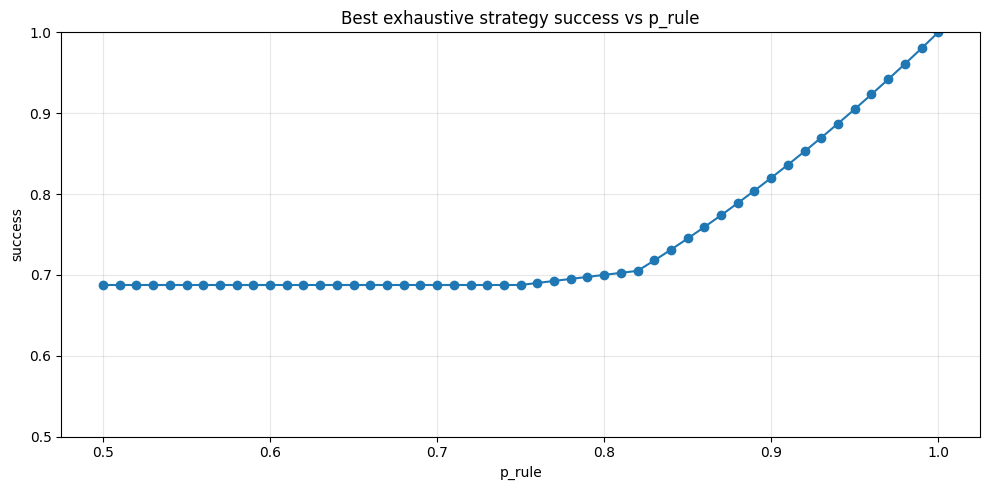

In [5]:
best_df = df[df["rank"] == 1].copy()

if best_df.empty:
    idx = df.groupby("p_rule")["success"].idxmax()
    best_df = df.loc[idx].copy()

best_df = best_df.sort_values("p_rule").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(best_df["p_rule"], best_df["success"], marker="o", linewidth=1.5)
plt.title("Best exhaustive strategy success vs p_rule")
plt.xlabel("p_rule")
plt.ylabel("success")
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


In [6]:
print("Best candidate by p_rule (sample):")
display(best_df[["p_rule", "candidate_name", "success"]].head(15))

print("\nValue counts of best candidate names across p_rule sweep:")
display(best_df["candidate_name"].value_counts())

Best candidate by p_rule (sample):


,p_rule,candidate_name,success
0,0.50,majority_n2_4_k_3_b_0,0.6875
1,0.51,majority_n2_4_k_3_b_0,0.6875
2,0.52,majority_n2_4_k_3_b_0,0.6875
3,0.53,majority_n2_4_k_3_b_0,0.6875
4,0.54,majority_n2_4_k_3_b_0,0.6875
5,0.55,majority_n2_4_k_3_b_0,0.6875
6,0.56,majority_n2_4_k_3_b_0,0.6875
7,0.57,majority_n2_4_k_3_b_0,0.6875
8,0.58,majority_n2_4_k_3_b_0,0.6875
9,0.59,majority_n2_4_k_3_b_0,0.6875



Value counts of best candidate names across p_rule sweep:


candidate_name
majority_n2_4_k_3_b_0                          25
pyramid_n2_4_k_3                               18
hybrid_horiz_maj_pyr_n2_4_k_3_split_2_2_b_0     7
hybrid_horiz_pyr_maj_n2_4_k_3_split_2_2_b_0     1
Name: count, dtype: int64

<a id="sec-b-side-limit"></a>
## Overal optimal strategy as a function of $p_{\text{rule}}$ limiting the effective PR box utilization at B-side

This sweep measures how many PR boxes are effectively utilized at B-side. It does NOT restrict player A separately. If `box_limit=2`, still 3-box strategies are generated and optimized, but the effective utilization by B is limited to 2



,box_limit,p_rule,success,candidate_name
0,0,0.50,0.6875,majority_n2_4_k_3_b_0
1,0,0.51,0.6875,majority_n2_4_k_3_b_0
2,0,0.52,0.6875,majority_n2_4_k_3_b_0
3,0,0.53,0.6875,majority_n2_4_k_3_b_0
4,0,0.54,0.6875,majority_n2_4_k_3_b_0
5,0,0.55,0.6875,majority_n2_4_k_3_b_0
6,0,0.56,0.6875,majority_n2_4_k_3_b_0
7,0,0.57,0.6875,majority_n2_4_k_3_b_0
8,0,0.58,0.6875,majority_n2_4_k_3_b_0
9,0,0.59,0.6875,majority_n2_4_k_3_b_0


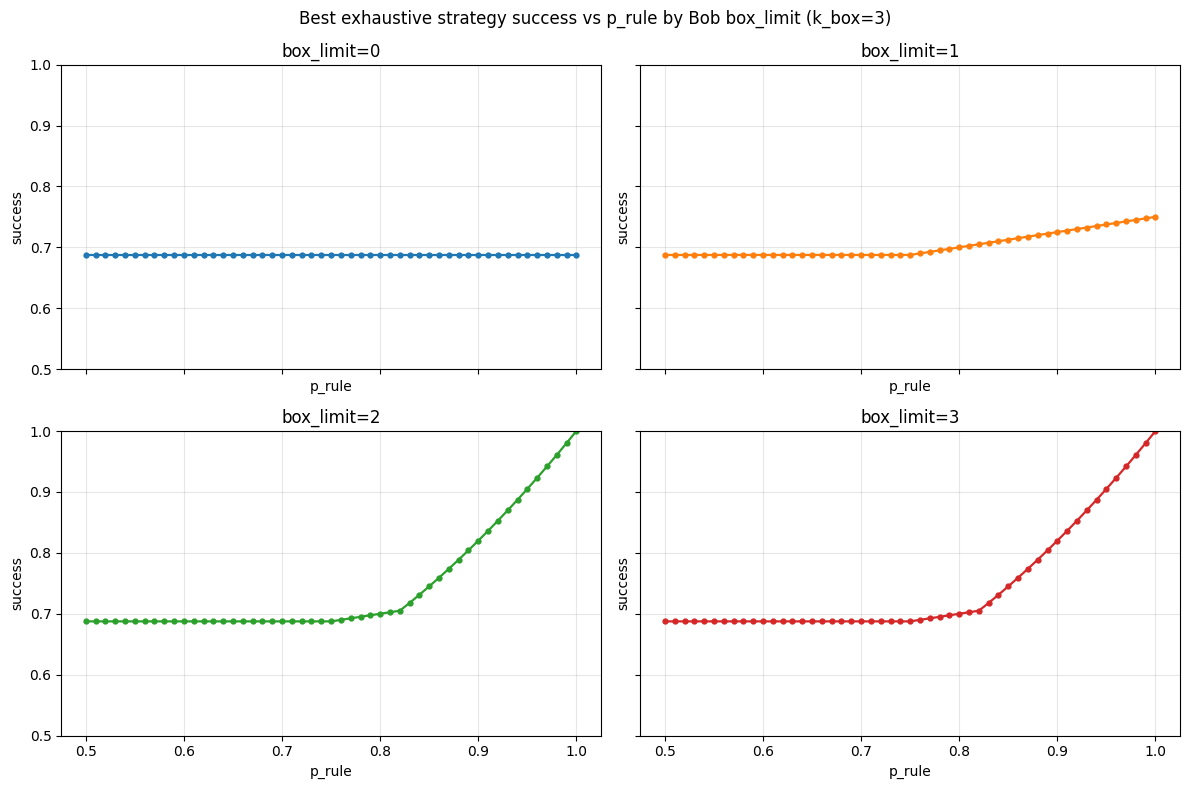

In [7]:
# Separate plots: best success vs p_rule for Bob box_limit in {0, 1, 2, 3}

box_limit_sweep = [0, 1, 2, 3]
fixed_k_box = int(k_box_values[0]) if k_box_values else 3

limit_rows = []

for box_limit in box_limit_sweep:
    sweep_output = project_root / "work" / "qsg" / f"p_rule_curve_exhaustive_k_{fixed_k_box}_limit_{box_limit}.json"

    cmd_limit = [
        sys.executable,
        str(script_path),
        "--mode", mode,
        "--p-rules", *map(str, p_rules),
        "--n2-values", *map(str, n2_values),
        "--k-box-values", str(fixed_k_box),
        "--box-limit", str(box_limit),
        "--subset-policy", "up_to",
        "--families", *families,
        "--top-k", str(top_k),
        "--cache-enabled",
        "--json-output", str(sweep_output),
        "--quiet",
    ]

    try:
        completed_limit = subprocess.run(
            cmd_limit,
            cwd=project_root,
            check=True,
            text=True,
            capture_output=True,
        )
        if completed_limit.stderr.strip():
            print(f"box_limit={box_limit} stderr (non-fatal):")
            print(completed_limit.stderr)
    except subprocess.CalledProcessError as exc:
        print(f"CLI failed for box_limit={box_limit}.")
        if exc.stderr:
            print("stderr:")
            print(exc.stderr)
        if exc.stdout:
            print("stdout:")
            print(exc.stdout)
        raise

    with sweep_output.open("r", encoding="utf-8") as f:
        payload_limit = json.load(f)

    for entry in payload_limit.get("results", []):
        p_rule_val = float(entry["p_rule"])
        ranked = entry.get("ranked_results", [])
        if not ranked:
            continue

        top_item = min(ranked, key=lambda r: int(r["rank"]))
        limit_rows.append(
            {
                "box_limit": box_limit,
                "p_rule": p_rule_val,
                "success": float(top_item["success"]),
                "candidate_name": str(top_item["candidate_name"]),
            }
        )

limit_df = pd.DataFrame(limit_rows).sort_values(["box_limit", "p_rule"]).reset_index(drop=True)
display(limit_df.head(12))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

color_map = {0: "tab:blue", 1: "tab:orange", 2: "tab:green", 3: "tab:red"}

for i, box_limit in enumerate(box_limit_sweep):
    ax = axes[i]
    curve = limit_df[limit_df["box_limit"] == box_limit].sort_values("p_rule")

    if curve.empty:
        ax.set_title(f"box_limit={box_limit} (no data)")
        ax.grid(True, alpha=0.3)
        continue

    ax.plot(
        curve["p_rule"],
        curve["success"],
        marker="o",
        linewidth=1.6,
        markersize=3.5,
        color=color_map.get(box_limit),
    )
    ax.set_title(f"box_limit={box_limit}")
    ax.set_xlabel("p_rule")
    ax.set_ylabel("success")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 1.0)

fig.suptitle(f"Best exhaustive strategy success vs p_rule by Bob box_limit (k_box={fixed_k_box})")
fig.tight_layout()
plt.show()

<a id="sec-a-side-limit"></a>
## Overal optimal strategy as a function of $p_{\text{rule}}$ limiting the effective PR box utilization at A-side

This sweep measures how many PR boxes exist in the protocol at A-side. It does NOT restrict Bob separately. If `k_box=2`, only 2-box strategies are generated and optimized.

This differs from the Bob decision-output limit above, where a 3-box strategy may still allow Bob to inspect only 2 outputs.

In [8]:
protocol_limits = [0, 1, 2, 3]

protocol_rows = []

for protocol_limit in protocol_limits:
    sweep_output = project_root / "work" / "qsg" / f"protocol_limit_{protocol_limit}.json"

    cmd_protocol = [
        sys.executable,
        str(script_path),
        "--mode", mode,
        "--p-rules", *map(str, p_rules),
        "--n2-values", *map(str, n2_values),
        "--k-box-values", str(protocol_limit),
        "--families", *families,
        "--top-k", str(top_k),
        "--cache-enabled",
        "--json-output", str(sweep_output),
        "--quiet",
    ]

    try:
        completed_protocol = subprocess.run(
            cmd_protocol,
            cwd=project_root,
            check=True,
            text=True,
            capture_output=True,
        )
        if completed_protocol.stderr.strip():
            print(f"protocol_limit={protocol_limit} stderr (non-fatal):")
            print(completed_protocol.stderr)
    except subprocess.CalledProcessError as exc:
        print(f"CLI failed for protocol_limit={protocol_limit}.")
        if exc.stderr:
            print("stderr:")
            print(exc.stderr)
        if exc.stdout:
            print("stdout:")
            print(exc.stdout)
        raise

    with sweep_output.open("r", encoding="utf-8") as f:
        payload_protocol = json.load(f)

    for entry in payload_protocol.get("results", []):
        p_rule_val = float(entry["p_rule"])
        ranked_results = entry.get("ranked_results", [])
        if not ranked_results:
            continue

        rank_one = [item for item in ranked_results if int(item.get("rank", 10**9)) == 1]
        if rank_one:
            best_item = rank_one[0]
        else:
            best_item = max(ranked_results, key=lambda item: float(item["success"]))

        protocol_rows.append(
            {
                "p_rule": p_rule_val,
                "success": float(best_item["success"]),
                "protocol_limit": protocol_limit,
            }
        )

protocol_df = pd.DataFrame(protocol_rows).sort_values(["protocol_limit", "p_rule"]).reset_index(drop=True)
display(protocol_df.head(12))


,p_rule,success,protocol_limit
0,0.50,0.6875,0
1,0.51,0.6875,0
2,0.52,0.6875,0
3,0.53,0.6875,0
4,0.54,0.6875,0
5,0.55,0.6875,0
6,0.56,0.6875,0
7,0.57,0.6875,0
8,0.58,0.6875,0
9,0.59,0.6875,0


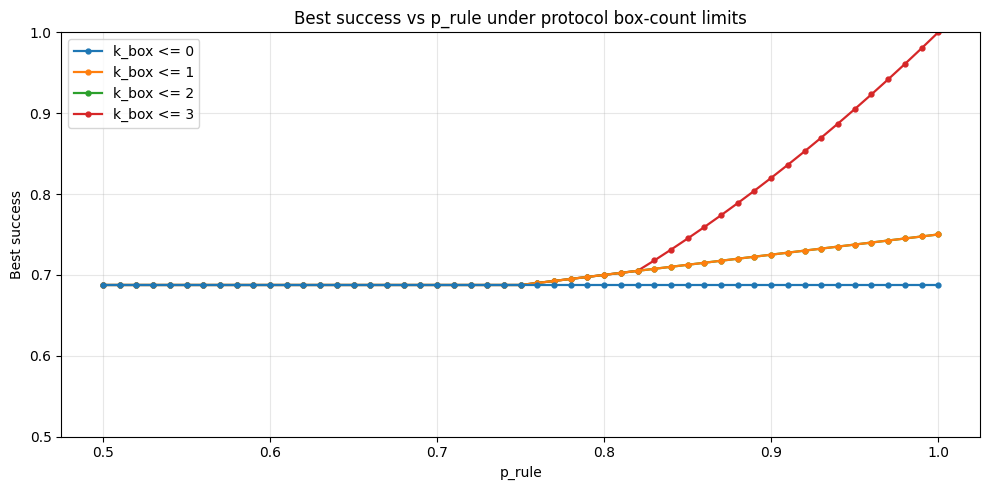

In [9]:
plt.figure(figsize=(10, 5))
color_map = {0: "tab:blue", 1: "tab:orange", 2: "tab:green", 3: "tab:red"}
label_map = {0: "k_box <= 0", 1: "k_box <= 1", 2: "k_box <= 2", 3: "k_box <= 3"}

# Plot higher k_box first so lower k_box is drawn last (on top) where curves overlap.
for protocol_limit in sorted(protocol_limits, reverse=True):
    curve = protocol_df[protocol_df["protocol_limit"] == protocol_limit].sort_values("p_rule")
    if curve.empty:
        continue

    plt.plot(
        curve["p_rule"],
        curve["success"],
        marker="o",
        linewidth=1.6,
        markersize=3.5,
        color=color_map.get(protocol_limit),
        label=label_map[protocol_limit],
    )

plt.title("Best success vs p_rule under protocol box-count limits")
plt.xlabel("p_rule")
plt.ylabel("Best success")
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.0)

# Keep legend ordered by increasing protocol limit.
handles, labels = plt.gca().get_legend_handles_labels()
legend_order = [
    label_map[k]
    for k in sorted(protocol_limits)
    if label_map[k] in labels
]
ordered_handles = [handles[labels.index(lbl)] for lbl in legend_order]
plt.legend(ordered_handles, legend_order)

plt.tight_layout()
plt.show()

<a id="sec-reference"></a>
## Reference

- Author: Rob Hendriks
- Copyright: © 2026 SSF contributors
- GitHub: https://github.com/robhendrik/SSF